# Support Vector Machine Notebook

In [ ]:
##########
# Library Imports
## Not all libraries are imported in this first cell as a way to spare some computing power
##########

import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the CSV file with metadata
bee_data = pd.read_csv("../data/processed/processed_bee_data_20260330_151740.csv", sep=';')

# Top 5 lines
display(bee_data.head())

# Information on simple shape of dataset imported
print(bee_data.shape)

# Further information on dataset
display(bee_data.describe(include="all").T)

,file,health,split_group
0,040_070.png,unhealthy,train
1,040_328.png,unhealthy,train
2,010_441.png,healthy,train
3,015_770.png,healthy,train
4,038_149.png,unhealthy,train


(5172, 3)


,count,unique,top,freq
file,5172,5172,040_070.png,1
health,5172,2,healthy,3384
split_group,5172,3,train,4137


In [ ]:
# Necessary features (X) and target (y)
x = bee_data[['file']].copy()
y = bee_data['health'].copy()

# Use the predefined split groups from processed metadata
split_col = bee_data['split_group'].str.lower()

x_train = x[split_col == 'train']
y_train = y[split_col == 'train']

x_val = x[split_col == 'val']
y_val = y[split_col == 'val']

x_test = x[split_col == 'test']
y_test = y[split_col == 'test']

# Shape / # rows, # columns for each split
print("Training")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("\nValidation")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")
print("\nTesting")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Number of unique classes
num_classes_train = len(np.unique(y_train))
num_classes_val = len(np.unique(y_val))
num_classes_test = len(np.unique(y_test))

print(f"Number of classes in training set: {num_classes_train}")
print(f"Number of classes in validation set: {num_classes_val}")
print(f"Number of classes in test set: {num_classes_test}\n")

# Quick check for train-test-val counts
print(bee_data[['file', 'split_group']].head(10), "\n")
print(bee_data['split_group'].value_counts())

Training
x_train shape: (4137, 1)
y_train shape: (4137,)

Validation
x_val shape: (517, 1)
y_val shape: (517,)

Testing
x_test shape: (518, 1)
y_test shape: (518,)

Number of classes in training set: 2
Number of classes in validation set: 2
Number of classes in test set: 2

           file split_group
0   040_070.png       train
1   040_328.png       train
2   010_441.png       train
3   015_770.png       train
4   038_149.png       train
5   032_361.png       train
6  019_1354.png       train
7  015_1260.png       train
8   032_547.png       train
9   040_363.png       train 

split_group
train    4137
test      518
val       517
Name: count, dtype: int64


# Prepare image paths for the handcrafted feature extraction for SVM

In [ ]:
# The image size is fixed (128x128) so all extracted features are based on the same input dimensions
IMG_SIZE = 128  # keep consistent with cv2.resize in feature extraction

# File paths for the train, validation, and test images
def make_paths(file_series):
    return file_series.astype(str).apply(
        lambda name: os.path.join("../data/bee_imgs", name)
    ).to_numpy()

train_paths = make_paths(x_train.iloc[:, 0])
val_paths = make_paths(x_val.iloc[:, 0])
test_paths = make_paths(x_test.iloc[:, 0])

# Print summary of how many images are available in each split
print(f"Train samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")
print(f"Feature extraction image size: {IMG_SIZE}x{IMG_SIZE}")

Train samples: 4137
Validation samples: 517
Test samples: 518
Feature extraction image size: 128x128


## Handcrafted Feature Extraction

(Disclaimer: This description is the exact same as it is in random_forest.ipynb, but pasted here too, in the case if someone would read this notebook first.)

Traditional machine learning models, also like SVM can't learn useful image features automatically in the same way as CNNs. Because of this, each image first needs to be converted into a smaller, numerical feature vector.

- The resized input image has a size of 128 x 128 x 3, which corresponds to 49,152 raw pixel values.
- Using all raw pixel values directly would make training less efficient for a traditional model.
- Handcrafted features reduce dimensionality while still keeping important visual information.
- Resulting: the final feature vector contains 8,154 values per image.
- The extracted features combine HOG descriptors, HSV color histograms, and RGB channel statistics (mean and standard deviation).

This makes the data easier for the SVM to process. More details about the feature choice are discussed in the bachelor thesis.

In [ ]:
import cv2
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler

# Handcrafted feature extraction functions
# These features summarize texture, color distribution, and simple color statistics
def extract_features(img_bgr: np.ndarray) -> np.ndarray:
    """
    img_bgr: uint8 array (H, W, 3) in BGR format from cv2.imread.
    Returns: 1-D float32 feature vector.
    """
    img = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))

    # 1) HOG on grayscale: captures texture and local shape information
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feats = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )

    # 2) HSV histogram: captures the color distribution of the image
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_hist = np.concatenate([
        cv2.calcHist([hsv], [ch], None, [16], [0, 256]).flatten()
        for ch in range(3)
    ])

    # 3) RGB channel statistics: mean and standard deviation for each color channel
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    rgb_stats = np.concatenate([
        [rgb[:, :, ch].mean(), rgb[:, :, ch].std()]
        for ch in range(3)
    ])

    return np.concatenate([hog_feats, hsv_hist, rgb_stats]).astype(np.float32)

# Apply the same feature extraction process to every image in a dataset split
def extract_dataset(image_paths):
    """Extract features for a list/array of image paths."""
    feats = []
    for path in image_paths:
        img = cv2.imread(str(path))
        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")
        feats.append(extract_features(img))
    return np.vstack(feats)

# Build feature matrices for the train, validation, and test sets
x_train_features = extract_dataset(train_paths)
x_val_features = extract_dataset(val_paths)
x_test_features = extract_dataset(test_paths)


print(f"x_train_features shape: {x_train_features.shape}")
print(f"x_val_features shape: {x_val_features.shape}")
print(f"x_test_features shape: {x_test_features.shape}")

# Standardize the features -> similar scale
# The scaler is fitted only on the training data and then applied to validation and test data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_features)
x_val_scaled = scaler.transform(x_val_features)
x_test_scaled = scaler.transform(x_test_features)

x_train_features shape: (4137, 8154)
x_val_features shape: (517, 8154)
x_test_features shape: (518, 8154)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Train the SVM model using the handcrafted image features from the previous cell
# Hyperparameter tuning can be turned on if a more detailed search is needed
use_grid_search = False  # Set to True for Hyperparameter tuning

# Use the extracted feature vectors as input for the SVM
X_train = x_train_features
y_train_labels = y_train.astype(str)

# Build a baseline SVM
# StandardScaler is applied before SVM (feature scaling improves SVM performance)
baseline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        random_state=42,
    )),
])

# Measure training time training time can be compared
training_start_time = time.perf_counter()
if use_grid_search:
    print("Running GridSearchCV for SVM hyperparameters...")
    param_grid = {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.001, 0.01],
    }

    # GridSearchCV tests different parameter combinations using cross-validation (3-fold)
    search = GridSearchCV(
        baseline_svm,
        param_grid=param_grid,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=2,
        refit=True,
    )

    search.fit(X_train, y_train_labels)
    best_svm = search.best_estimator_

    print("Best params:", search.best_params_)
    print("Best CV f1_macro:", f"{search.best_score_:.4f}")
else:
    # SVM model using the best-performing settings from earlier experiments
    print("Running baseline SVM without hyperparameter search...")
    best_svm = baseline_svm.fit(X_train, y_train_labels)

training_end_time = time.perf_counter()
training_time_for_model = training_end_time - training_start_time

print(f"Training time for model: {training_time_for_model:.2f} seconds")

# Result of hyperparameter tuning used in the final version
# Best params: {'clf__C': 10, 'clf__gamma': 'scale'}
# Best CV f1_macro: 0.8800


Running baseline SVM without hyperparameter search...
Training time for model: 60.32 seconds


# Final Model Evaluation

First I check performance from validation set, then finally on test set.
The evaluation metrics are:
- numeric values of Accuracy, Recall, Precision, F1-Score, ROC-AUC Score
- Confusion Matrix
- ROC-AUC Curve

Validation classification report:
              precision    recall  f1-score   support

     healthy       0.90      0.98      0.94       338
   unhealthy       0.95      0.80      0.87       179

    accuracy                           0.92       517
   macro avg       0.93      0.89      0.90       517
weighted avg       0.92      0.92      0.92       517

Prediction time for model: 9.84 seconds

Test set classification report:
              precision    recall  f1-score   support

     healthy       0.92      0.96      0.94       339
   unhealthy       0.91      0.84      0.87       179

    accuracy                           0.92       518
   macro avg       0.91      0.90      0.90       518
weighted avg       0.91      0.92      0.91       518

Summary metrics (positive class = unhealthy):
Accuracy:  0.9151
Precision: 0.9091
Recall:    0.8380
F1-score:  0.8721
ROC-AUC:   0.9686


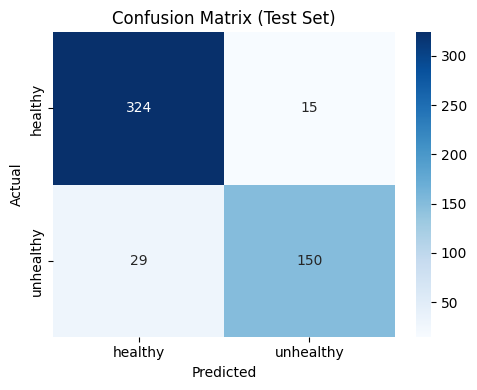

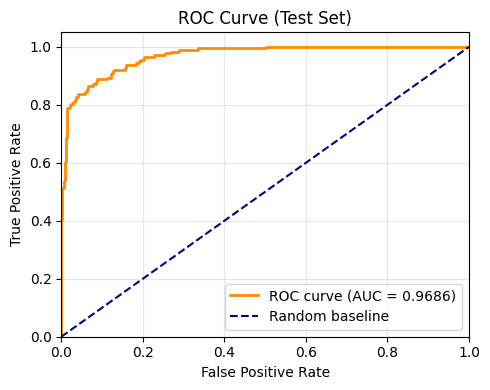

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc, 
    confusion_matrix, 
    classification_report, 
    accuracy_score
    )

# First check performance on the validation set before final test evaluation
X_val = x_val_features
y_val_labels = y_val.astype(str).to_numpy()
y_val_pred = best_svm.predict(X_val)

print("Validation classification report:")
print(classification_report(y_val_labels, y_val_pred))

# Final evaluation of SVM model on the held out test set
# Prediction time measured so runtime can be compared with other models
prediction_start_time = time.perf_counter()

X_test = x_test_features
y_test_labels = y_test.astype(str).to_numpy()
y_pred = best_svm.predict(X_test)

prediction_end_time = time.perf_counter()
prediction_time_for_model = prediction_end_time - prediction_start_time
print(f"Prediction time for model: {prediction_time_for_model:.2f} seconds")

# Calculate the main classification metrics on the test set
acc = accuracy_score(y_test_labels, y_pred)
prec = precision_score(y_test_labels, y_pred, pos_label="unhealthy")
rec = recall_score(y_test_labels, y_pred, pos_label="unhealthy")
f1 = f1_score(y_test_labels, y_pred, pos_label="unhealthy")

# ROC-AUC is calculated by treating the label "unhealthy" as the positive class
# For SVM, decision_function scores are used instead of class probabilities
y_test_binary = (y_test_labels == "unhealthy").astype(int)
y_score = best_svm.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

print("\nTest set classification report:")
print(classification_report(y_test_labels, y_pred))

print("Summary metrics (positive class = unhealthy):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion matrix shows how many healthy and unhealthy images were classified correctly or incorrectly
cm = confusion_matrix(y_test_labels, y_pred, labels=["healthy", "unhealthy"] )

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "unhealthy"],
    yticklabels=["healthy", "unhealthy"],
)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# The ROC curve shows how well the model can separate two classes
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", linewidth=1.5, linestyle="--", label="Random baseline")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()